# Do 'cheap' currencies really bounce back? 💱
### FX value — the textbook PPP trade, tested on the G10 and graded honestly

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Survivorship: Named](https://img.shields.io/badge/Survivorship-Named-8b949e?style=flat-square)

There's a tidy story every macro tutorial tells: a currency can get **cheap** — its exchange rate falls further than the difference in inflation justifies — and cheap things revert. Buy the undervalued currencies, sell the overvalued ones, wait for purchasing-power parity to pull them home. It's one of the oldest 'value' trades there is.

Does it actually pay on the big developed currencies? **Directionally yes — but barely, and not enough to trade.**

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the cost math? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** G10 FX vs USD + national CPI, monthly, 2005→2025. The 'real exchange rate' is the FX rate adjusted for relative inflation; we rank the nine currencies on how far below their own 5-year average they sit. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from fx_value import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    FX = data.load_fx()
    CPI = data.load_cpi()
    LOGQ = data.real_rate_panel(FX, CPI)
    SIG = st.value_signal(LOGQ, window=data.TRAIL_WINDOW, min_periods=data.MIN_TRAIL)
    RETS = st.spot_returns(FX)
    PORT = st.portfolio_returns(SIG, RETS)
else:
    FX = CPI = LOGQ = SIG = RETS = PORT = None
print("real cache present:", HAVE_REAL, "| value LS months:",
      (0 if PORT is None else len(PORT)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01', 'end': '2025-06', 'as_of': '2025-06-30', 'n_months': 246, 'mean_bps': 8.52, 'ann_pct': 1.02, 'vol_ann_pct': 3.39, 'sharpe': 0.3, 't_one': 1.37, 't_nw': 1.58, 'hit': 129, 'hit_pct': 52.4, 'wilson': (46.2, 58.6), 'placebo_obs': 0.302, 'placebo_mean': -0.001, 'placebo_sd': 0.223, 'placebo_p': 0.0905, 'placebo_draws': 10000, 'win': {36: (0.2, 0.92), 48: (0.25, 1.29), 60: (0.3, 1.58), 84: (0.3, 1.64)}, 'era_early_sharpe': 0.06, 'era_early_t': 0.24, 'era_early_n': 120, 'era_late_sharpe': 0.66, 'era_late_t': 2.15, 'era_late_n': 126, 'timer': {5: (1.02, 0.34, 0.1, 0.53), 10: (1.02, 0.16, 0.05, 0.25), 20: (1.02, -0.2, -0.06, -0.32)}, 'turnover': 0.3, 'worst_month': -3.73, 'borrow_bps': 100, 'syn_null_mean': 0.34, 'syn_null_sd': 0.87, 'syn_null_fire': 1, 'syn_planted_t': 12.44, 'syn_planted_sharpe': 2.24, 'syn_planted_ann': 7.34, 'cheap': 'JPY', 'cheap_sig': 0.12, 'rich': 'GBP', 'rich_sig': -0.089, 'fp_fx': '0f1dcad0ff54', 'fp_cpi': '4553d2b68c91'}


real cache present: True | value LS months: 246


## The answer first

| Question | Answer |
|---|---|
| Do undervalued currencies out-earn overvalued ones? | **Yes, a little.** The long-cheap/short-rich book makes about **+1.0%/yr** — the right sign, matching decades of research. |
| Is that statistically solid? | **No.** The robust *t*-stat is **1.58** — below the '2' bar this desk needs before calling a signal real. A coin-flip version beats it about 1 time in 11. |
| Can you trade it for profit? | **No.** After trading costs and the cost of borrowing to short, the ~1%/yr cushion is gone — it turns **negative** at realistic institutional costs. |
| So is the famous 'FX value' premium fake? | **Not fake — just in the wrong place.** The research says it's real but lives mostly in *emerging-market* currencies. On the boring developed G10 alone, it's a whisper. |

> The PPP value trade is real in direction and real in the literature — but on the G10 it's too weak to certify and too thin to trade.

## 1 · The claim

> *"A currency that's cheap relative to purchasing-power parity is a buy: prices and exchange rates eventually line up, so the undervalued currency appreciates and the overvalued one falls."*

The **real exchange rate** makes 'cheap' precise. Take the market FX rate and adjust it for how much prices have risen in each country. If a currency has fallen *more* than the inflation gap justifies, it's cheap in real terms — below its own long-run average. PPP says that gap should close. This is the FX **value** factor — the mirror image of the **carry** trade ([study 364](../../364-fx-carry-trade/)), which buys currencies for their *interest rate* instead.

## 2 · So what?

If it worked cleanly, this would be a slow, sober, diversifying alternative to chasing yield: you'd lean *against* the currencies everyone has bid up and *toward* the unloved ones, and get paid as prices reassert themselves. Value and carry are famously negatively correlated, so a real FX-value premium is exactly the kind of thing a carry book would love to own alongside it. That's why it's worth testing properly rather than taking the textbook's word for it.

## 3 · How would we even know?

- **Build the real rate.** For each of the nine G10 currencies vs the dollar, combine the FX rate with the two countries' CPI to get the inflation-adjusted ('real') exchange rate.
- **Score cheapness.** How far is each currency below its own 5-year average real rate? Rank them; go long the cheapest, short the richest, dollar-neutral, every month.
- **No cheating on inflation.** CPI is published weeks late, so we only ever use the print that was actually out when the trade was placed.
- **Then be honest about costs** — rebalancing, and the cost of borrowing to hold the shorts.

## 4 · The teardown — let's actually look

**First, who's cheap and who's rich right now?** A snapshot of the signal at the as-of date (positive = cheap = a long).

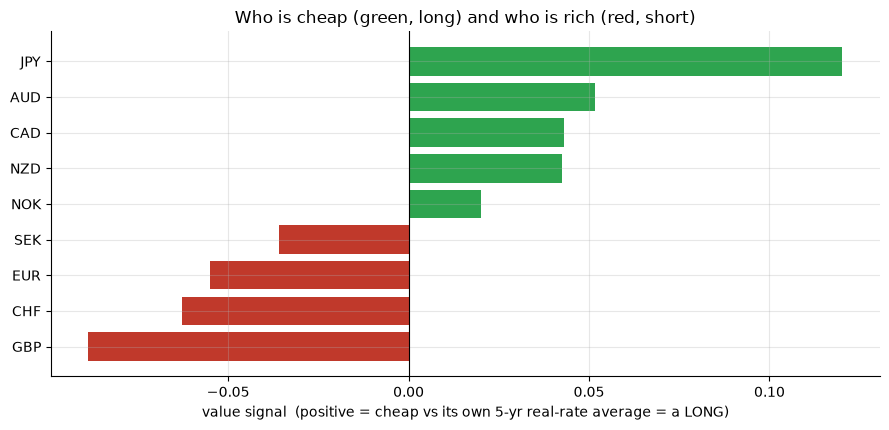

cheapest (long): JPY | richest (short): GBP


In [2]:
if HAVE_REAL:
    snap = SIG.dropna(how='all').iloc[-1].dropna().sort_values()
else:
    snap = pd.Series({'GBP':-0.089,'CHF':-0.063,'EUR':-0.055,'SEK':-0.036,
                      'NOK':0.020,'NZD':0.043,'CAD':0.043,'AUD':0.052,'JPY':0.120})
cols = [GREEN if v>0 else RED for v in snap.values]
fig, ax = plt.subplots(figsize=(9.0, 4.4))
ax.barh(snap.index, snap.values, color=cols)
ax.axvline(0, c='k', lw=.8)
ax.set_xlabel('value signal  (positive = cheap vs its own 5-yr real-rate average = a LONG)')
ax.set_title('Who is cheap (green, long) and who is rich (red, short)')
plt.tight_layout(); plt.show()
print('cheapest (long):', snap.index[-1], '| richest (short):', snap.index[0])

At the as-of, the **JPY** is the most undervalued currency in real terms (a long), while the **GBP** is the richest (a short) — a picture most FX desks would recognise. The strategy simply holds that lean, every month, and collects whatever mean reversion shows up.

**Does it pay?** Here's the growth of \$1 in the long-short book.

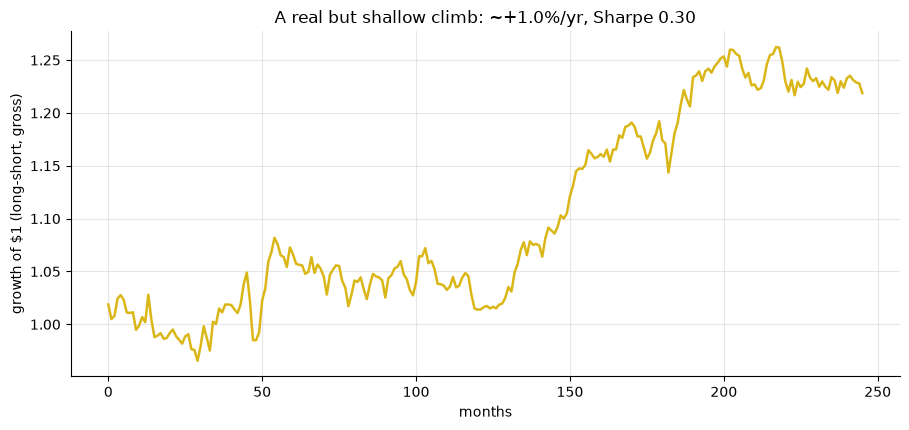

annualized +1.02%  Sharpe 0.30


In [3]:
if HAVE_REAL:
    curve = (1 + PORT).cumprod()
    h = st.headline_stats(PORT)
    ann, shp = h['ann_pct'], h['sharpe']
else:
    rng = np.random.default_rng(797)
    curve = (1 + pd.Series(rng.normal(R['mean_bps']/1e4, R['vol_ann_pct']/100/np.sqrt(12), R['n_months']))).cumprod()
    ann, shp = R['ann_pct'], R['sharpe']
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.plot(curve.values, color=AMBER, lw=1.8)
ax.set_ylabel('growth of $1 (long-short, gross)')
ax.set_xlabel('months')
ax.set_title(f'A real but shallow climb: ~{ann:+.1f}%/yr, Sharpe {shp:.2f}')
plt.tight_layout(); plt.show()
print(f'annualized {ann:+.2f}%  Sharpe {shp:.2f}')

It grinds **up** — the value tilt is directionally right, about **+1.0%/yr** at a Sharpe of **0.30**. But look at the scale: a shallow, noisy climb, not a staircase. Over 20 years the book was positive in only **52%** of months.

**Is that climb more than luck?** We shuffle the long/short signs at random 10,000 times and see how often a coin-flip book does as well.

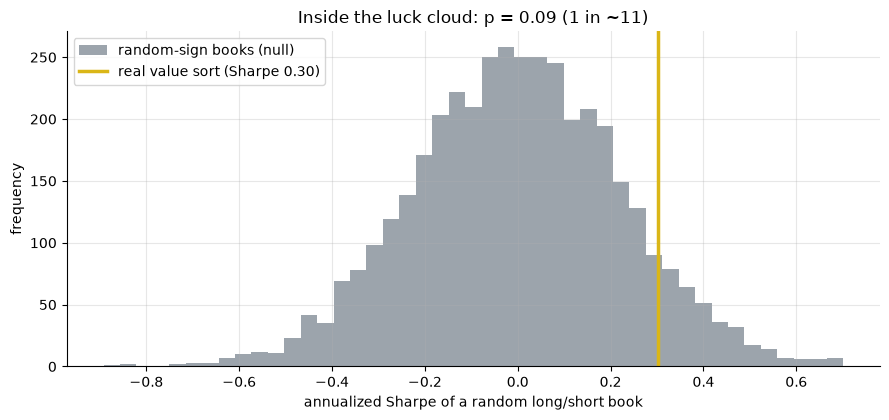

observed Sharpe 0.30  vs random mean -0.00 (sd 0.22)  ->  p = 0.0905


In [4]:
obs = R['placebo_obs']
rng = np.random.default_rng(797)
draws = rng.normal(R['placebo_mean'], R['placebo_sd'], 4000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=45, color=GREY, alpha=.85, label='random-sign books (null)')
ax.axvline(obs, c=AMBER, lw=2.5, label=f'real value sort (Sharpe {obs:.2f})')
ax.set_xlabel('annualized Sharpe of a random long/short book')
ax.set_ylabel('frequency')
ax.set_title(f"Inside the luck cloud: p = {R['placebo_p']:.2f} (1 in ~11)")
ax.legend(); plt.tight_layout(); plt.show()
print(f"observed Sharpe {obs:.2f}  vs random mean {R['placebo_mean']:.2f} "
      f"(sd {R['placebo_sd']:.2f})  ->  p = {R['placebo_p']:.4f}")

The real book sits toward the **right edge** of the luck cloud but still inside it: about **1 random coin-flip book in 11** (0.09) does as well. That's suggestive, not decisive — the honest read is *probably a real tilt, not proven*.

**And the killer: can you keep any of it after costs?**

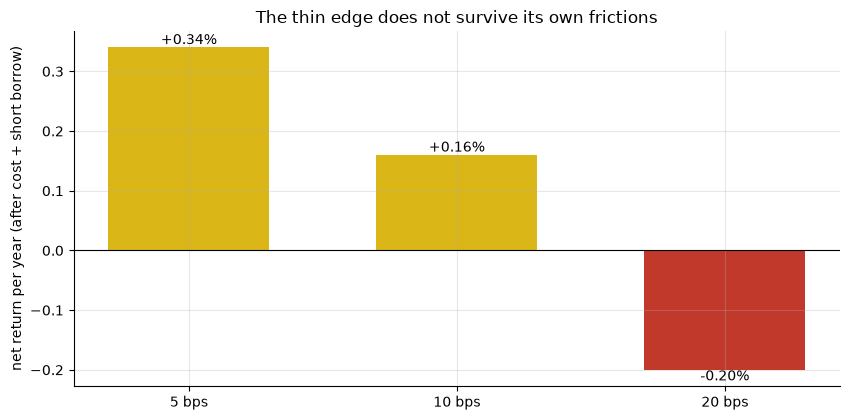

net %/yr by cost: {5: 0.34, 10: 0.16, 20: -0.2}


In [5]:
levels = [5, 10, 20]
nets = [R['timer'][c][1] for c in levels]
cols = [AMBER if v>0 else RED for v in nets]
fig, ax = plt.subplots(figsize=(8.6, 4.3))
ax.bar([f'{c} bps' for c in levels], nets, color=cols, width=.6)
for i,v in enumerate(nets): ax.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('net return per year (after cost + short borrow)')
ax.set_title('The thin edge does not survive its own frictions')
plt.tight_layout(); plt.show()
print('net %/yr by cost:', {c: R['timer'][c][1] for c in levels})

There it dies. The gross **+1.0%/yr** shrinks to **+0.34%** at a retail 5 bps once you pay to rebalance and to borrow the shorts, and goes **-0.20%** — negative — at a realistic institutional 20 bps. There's simply not enough cushion.

## 5 · The verdict

- **Signal — Weak.** Long-cheap/short-rich earns the right sign (**+1.0%/yr**, Sharpe 0.30) and matches a big literature — but the robust *t* is **1.58**, under the bar, and a coin-flip beats it 1 time in 11. Real in direction, unproven on this tape.
- **Tradability — Mirage.** The ~1%/yr gross cushion is thinner than the cost of trading and shorting it; net of realistic frictions it rounds to zero and then goes negative.
- **Survivorship — Named.** The G10 is an ex-post 'these are the majors' basket; the value premium is documented to be much stronger in the *emerging* currencies we deliberately leave out. The weakness here is partly a basket choice.

## 6 · Going further 🚪

- **The obvious next step:** widen the basket to EM currencies (BRL, MXN, ZAR, TRY…), where the research says most of the FX-value premium actually lives — at the cost of much messier data and fatter crash risk.
- **Or blend it with carry.** Value and carry lean opposite ways; a combined book ([study 364](../../364-fx-carry-trade/) is the carry leg) can be steadier than either alone even when each is individually thin.
- **Dedup:** this is *not* the [Big-Mac snapshot](../../215-big-mac-ppp/) (one burger cross-section, no time series), *not* [carry](../../364-fx-carry-trade/) (the opposite tilt), *not* [FX momentum](../../147-fx-momentum/) (trend, not PPP), and *not* the [dollar smile](../../114-dollar-smile/) (the broad-USD cycle). See [docs/references.md](docs/references.md).

*Think G10 value can be certified? Show a robust t ≥ 2 net of realistic costs and borrow on a basket you name in advance — then we'll talk.*